# Import dataset
Kaggle links = [Person Segmentation](https://www.kaggle.com/datasets/nikhilroxtomar/person-segmentation/versions/1) , [Human Segmentation Dataset - Supervise.ly](https://www.kaggle.com/datasets/tapakah68/supervisely-filtered-segmentation-person-dataset) , [Human Segmentation Dataset - TikTok Dance](https://www.kaggle.com/datasets/tapakah68/segmentation-full-body-tiktok-dancing-dataset)




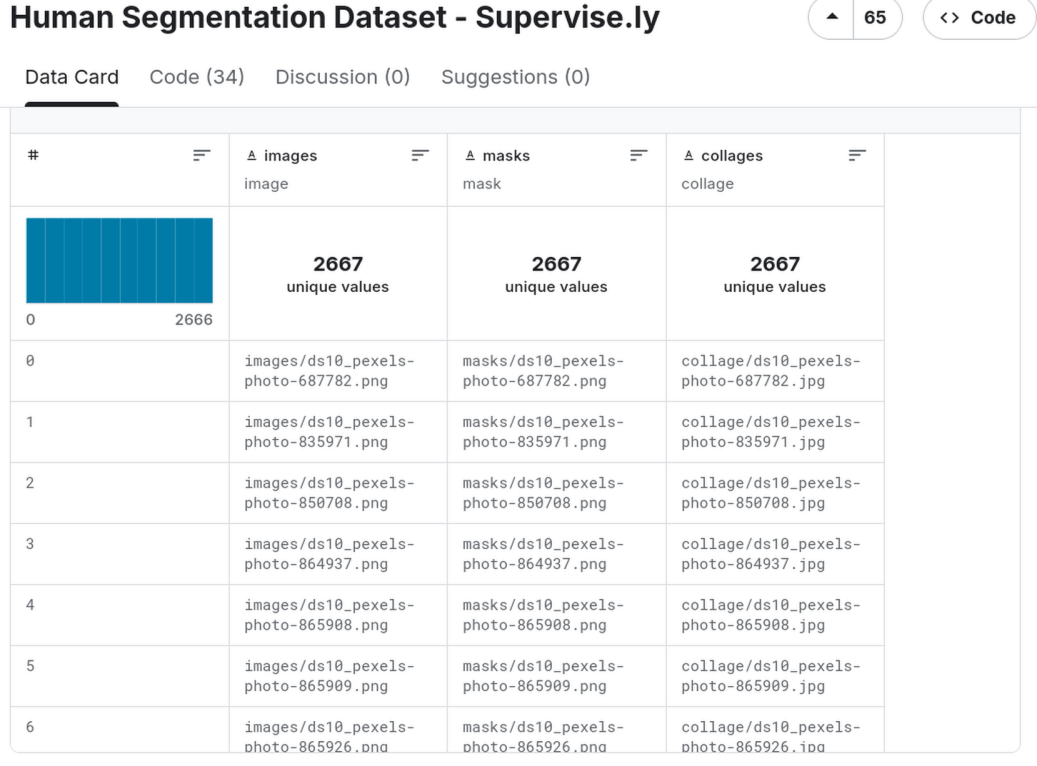

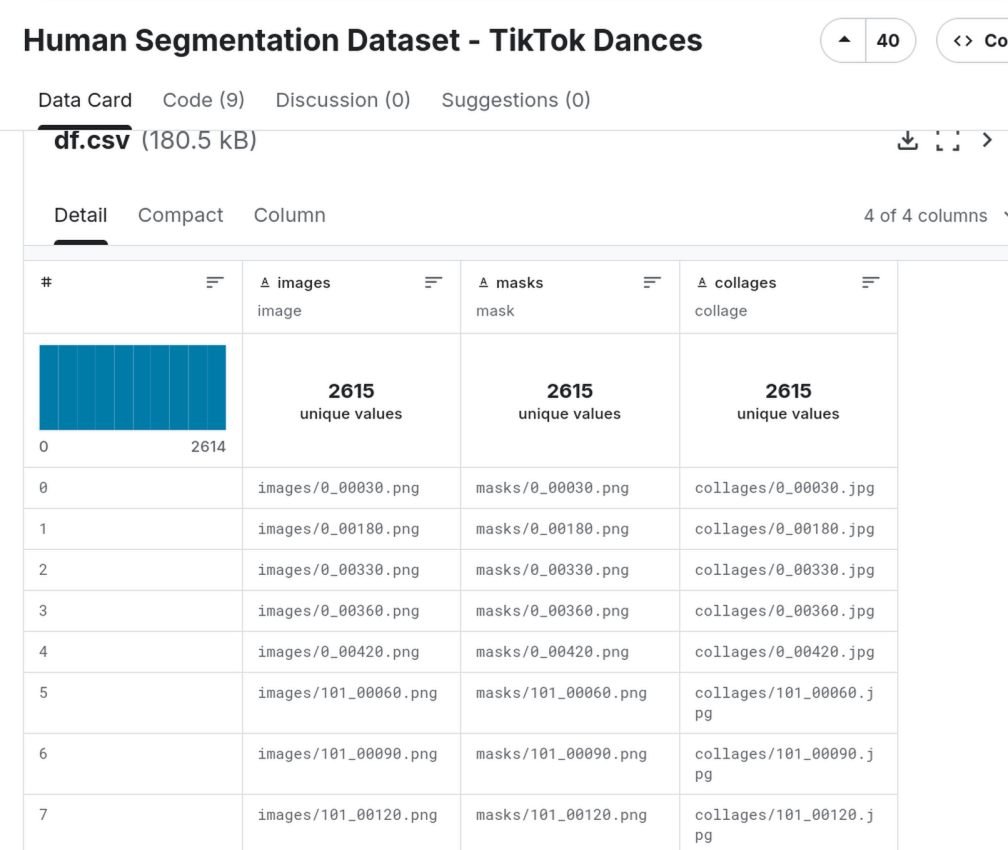

In [14]:
from __future__ import annotations

from pathlib import Path
from zipfile import ZipFile
import gdown


def download_and_extract_many_from_gdrive(
    files: dict[str, str],
    output_root: str,
    delete_zip: bool = True,
) -> dict[str, str]:

    root = Path(output_root)
    root.mkdir(parents=True, exist_ok=True)

    extracted_dirs: dict[str, str] = {}

    for folder_name, file_id in files.items():
        out_path = root / folder_name
        out_path.mkdir(parents=True, exist_ok=True)

        zip_path = out_path / f"{folder_name}.zip"
        url = f"https://drive.google.com/uc?id={file_id}"

        # Download
        gdown.download(url, str(zip_path), quiet=False)

        # Extract
        with ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(out_path)

        # Cleanup
        if delete_zip and zip_path.exists():
            zip_path.unlink()

        extracted_dirs[folder_name] = str(out_path)

    return extracted_dirs

In [15]:
FILES = {
    "person_segmentation": "1lbWAVnHnk3gCWJBCJK43EUnM34D7w2GH",
    "supervisely_person": "15kVoqVOQqXvDYZZ3PnZu9dv3NCcCIfAv",
    "tiktok_dance_segmentation": "1i4seE7Vpa9Ai31ZRbyLnYLk9zrRWP5_g",
}

paths = download_and_extract_many_from_gdrive(FILES, "../data/01_raw", delete_zip=True)
print(paths)

Downloading...
From (original): https://drive.google.com/uc?id=1lbWAVnHnk3gCWJBCJK43EUnM34D7w2GH
From (redirected): https://drive.google.com/uc?id=1lbWAVnHnk3gCWJBCJK43EUnM34D7w2GH&confirm=t&uuid=e3337d67-6dc8-49e8-bf41-9116a754c87a
To: /home/sam/Documents/AIAD/kedro/background-removal/data/01_raw/person_segmentation/person_segmentation.zip
100%|██████████| 483M/483M [00:06<00:00, 73.1MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=15kVoqVOQqXvDYZZ3PnZu9dv3NCcCIfAv
From (redirected): https://drive.google.com/uc?id=15kVoqVOQqXvDYZZ3PnZu9dv3NCcCIfAv&confirm=t&uuid=31e3613f-3d9e-47d1-8b74-e27b1e02d245
To: /home/sam/Documents/AIAD/kedro/background-removal/data/01_raw/supervisely_person/supervisely_person.zip
100%|██████████| 4.62G/4.62G [00:44<00:00, 105MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1i4seE7Vpa9Ai31ZRbyLnYLk9zrRWP5_g
From (redirected): https://drive.google.com/uc?id=1i4seE7Vpa9Ai31ZRbyLnYLk9zrRWP5_g&confirm=t&uuid=28ed5b76-e954-4

{'person_segmentation': '../data/01_raw/person_segmentation', 'supervisely_person': '../data/01_raw/supervisely_person', 'tiktok_dance_segmentation': '../data/01_raw/tiktok_dance_segmentation'}


# Import librarys

In [16]:
import os
import random
import numpy as np 
import pandas as pd 
from pathlib import Path
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import layers, models, optimizers, losses, metrics



In [60]:
# --- Supervisely (df.csv) ---
df_sup = pd.read_csv("../data/01_raw/supervisely_person/df.csv")

# IMPORTANT: fix these to the real folders
# From your earlier tree, your supervisely dataset seems extracted into a folder like:
# ../data/01_raw/supervisely_person/<something>/
# Update these two paths if needed.
SUP_ROOT = Path("../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img")

# If your CSV already includes subfolders, keep it. Otherwise it'll just append filename.
df_sup = df_sup[["images", "masks"]].copy()
df_sup["images"] = df_sup["images"].apply(lambda x: str(SUP_ROOT / x))
df_sup["masks"]  = df_sup["masks"].apply(lambda x: str(SUP_ROOT / x))

df_sup["source"] = "supervisely"

In [61]:
# --- Person Segmentation ---
PS_IMG_DIR = Path("../data/01_raw/person_segmentation/people_segmentation/images")
PS_MSK_DIR = Path("../data/01_raw/person_segmentation/people_segmentation/masks")

ps_imgs = sorted([p for p in PS_IMG_DIR.iterdir() if p.is_file()])
ps_msks = sorted([p for p in PS_MSK_DIR.iterdir() if p.is_file()])

# Pair by filename stem (safer than relying on sort order)
img_map  = {p.stem: str(p) for p in ps_imgs}
msk_map  = {p.stem: str(p) for p in ps_msks}
common   = sorted(set(img_map) & set(msk_map))

df_ps = pd.DataFrame({
    "images": [img_map[k] for k in common],
    "masks":  [msk_map[k] for k in common],
    "source": "person_segmentation",
})

In [62]:
final_df = pd.concat([df_sup, df_ps], ignore_index=True)

# sanity check missing files
missing_img = final_df[~final_df["images"].apply(lambda p: Path(p).exists())]
missing_msk = final_df[~final_df["masks"].apply(lambda p: Path(p).exists())]

print("Total rows:", len(final_df))
print("Missing images:", len(missing_img))
print("Missing masks :", len(missing_msk))

Total rows: 8345
Missing images: 0
Missing masks : 0


In [63]:
train_df, val_df = train_test_split(final_df, test_size=0.1, random_state=42, shuffle=True)

print("train:", len(train_df), "val:", len(val_df))
print(train_df["source"].value_counts())

train: 7510 val: 835
person_segmentation    5106
supervisely            2404
Name: source, dtype: int64


In [64]:
IMG_SIZE = 512
AUTOTUNE = tf.data.AUTOTUNE

def decode_mask(mask_path):
    m_bytes = tf.io.read_file(mask_path)
    # decode_image handles png/jpg automatically
    m = tf.image.decode_image(m_bytes, channels=1, expand_animations=False)
    m = tf.image.resize(m, (IMG_SIZE, IMG_SIZE), method="nearest")

    # ensure float32 for logic
    m = tf.cast(m, tf.float32)

    # If mask is 0/1 already, keep it. Otherwise threshold.
    m_max = tf.reduce_max(m)
    m = tf.cond(
        m_max <= 1.0,
        lambda: tf.cast(m > 0.5, tf.float32),
        lambda: tf.cast(m > 127.0, tf.float32)
    )
    return m
def decode_pair(img_path, mask_path):
    img_bytes = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    m = decode_mask(mask_path)
    return img, m
def augment(img, mask):
    # random horizontal flip
    flip = tf.random.uniform([]) > 0.5
    img  = tf.cond(flip, lambda: tf.image.flip_left_right(img),  lambda: img)
    mask = tf.cond(flip, lambda: tf.image.flip_left_right(mask), lambda: mask)

    # brightness
    img = tf.image.random_brightness(img, 0.2)

    # gaussian noise
    noise = tf.random.normal(tf.shape(img), stddev=0.05)
    img = tf.clip_by_value(img + noise, 0.0, 1.0)

    return img, mask

def make_dataset(df: pd.DataFrame, batch_size=4, training=False, buffer_size=256):
    img_paths = df["images"].astype(str).tolist()
    msk_paths = df["masks"].astype(str).tolist()

    ds = tf.data.Dataset.from_tensor_slices((img_paths, msk_paths))

    if training:
        ds = ds.shuffle(buffer_size, reshuffle_each_iteration=True)

    ds = ds.map(decode_pair, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(1)  # keeps RAM stable
    return ds

In [65]:
train_dataset = make_dataset(train_df, batch_size=4, training=True, buffer_size=256)
val_dataset   = make_dataset(val_df,   batch_size=4, training=False)



In [66]:
import random
from PIL import Image
import numpy as np
from pathlib import Path

def inspect_masks(df, n=10):
    rows = df.sample(n, random_state=1)
    for i, r in rows.iterrows():
        mp = Path(r["masks"])
        ip = Path(r["images"])
        if not mp.exists():
            print("MISSING MASK:", mp, "| image:", ip)
            continue

        arr = np.array(Image.open(mp))
        print(
            f"{mp.suffix.lower():>5}  shape={arr.shape}  min={arr.min()} max={arr.max()}  source={r.get('source','?')}"
        )

inspect_masks(final_df, n=10)

 .png  shape=(767, 1024)  min=0 max=1  source=person_segmentation
 .png  shape=(1024, 690)  min=0 max=1  source=person_segmentation
 .png  shape=(800, 1200, 3)  min=0 max=255  source=supervisely
 .png  shape=(682, 1024)  min=0 max=1  source=person_segmentation
 .png  shape=(800, 810)  min=0 max=1  source=person_segmentation
 .png  shape=(681, 1024)  min=0 max=1  source=person_segmentation
 .png  shape=(800, 533)  min=0 max=1  source=person_segmentation
 .png  shape=(800, 530)  min=0 max=1  source=person_segmentation
 .png  shape=(583, 1024)  min=0 max=1  source=person_segmentation
 .png  shape=(682, 1024)  min=0 max=1  source=person_segmentation



=== SOURCE: person_segmentation | showing 5 samples ===
[0] img: ../data/01_raw/person_segmentation/people_segmentation/images/pexels-photo-256639.jpg
    msk: ../data/01_raw/person_segmentation/people_segmentation/masks/pexels-photo-256639.png
[1] img: ../data/01_raw/person_segmentation/people_segmentation/images/beauty-woman-portrait-face-89790.jpg
    msk: ../data/01_raw/person_segmentation/people_segmentation/masks/beauty-woman-portrait-face-89790.png
[2] img: ../data/01_raw/person_segmentation/people_segmentation/images/pexels-photo-842912.jpg
    msk: ../data/01_raw/person_segmentation/people_segmentation/masks/pexels-photo-842912.png
[3] img: ../data/01_raw/person_segmentation/people_segmentation/images/old-people-couple-together-connected.jpg
    msk: ../data/01_raw/person_segmentation/people_segmentation/masks/old-people-couple-together-connected.png
[4] img: ../data/01_raw/person_segmentation/people_segmentation/images/pexels-photo-757456.jpg
    msk: ../data/01_raw/person_s

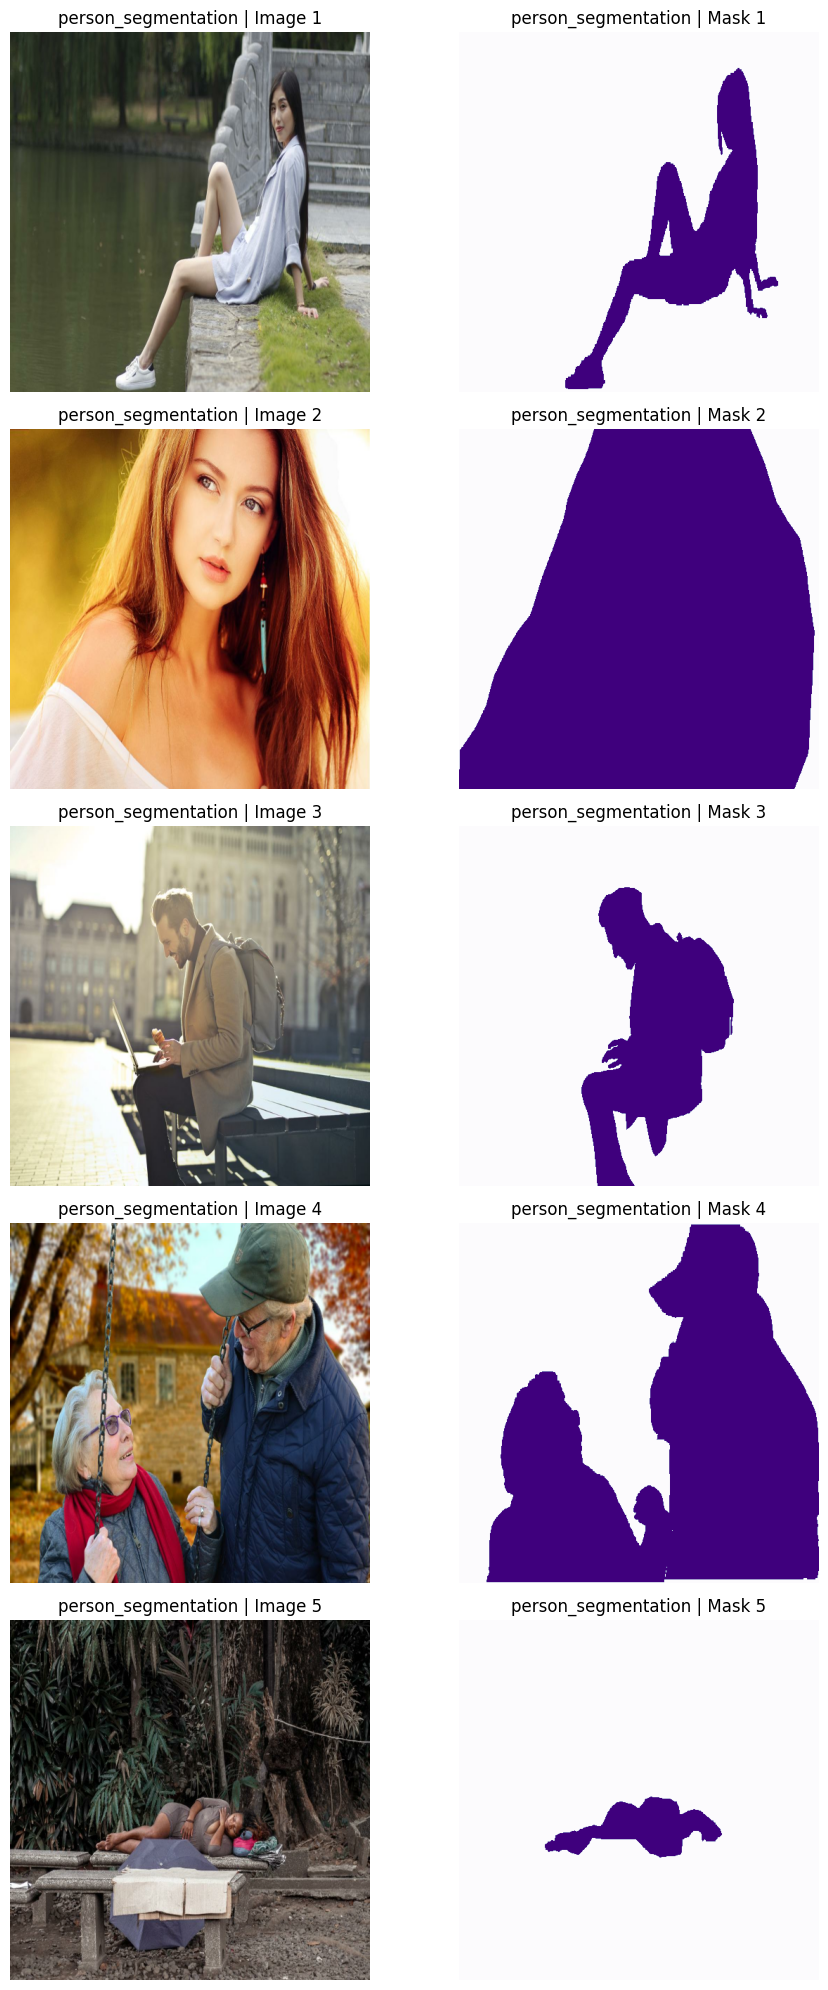


=== SOURCE: supervisely | showing 5 samples ===
[0] img: ../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/images/ds8_pexels-photo-731784.png
    msk: ../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/masks/ds8_pexels-photo-731784.png
[1] img: ../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/images/ds1_pexels-photo-48566.png
    msk: ../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/masks/ds1_pexels-photo-48566.png
[2] img: ../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/images/ds7_pexels-photo-720276.png
    msk: ../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/supervisely_person_clean_2667_img/masks/ds7_pexels-photo-720276.png
[3] img: ../data/01_raw/supervisely_person/supervisely_person_clean_2667_img/sup

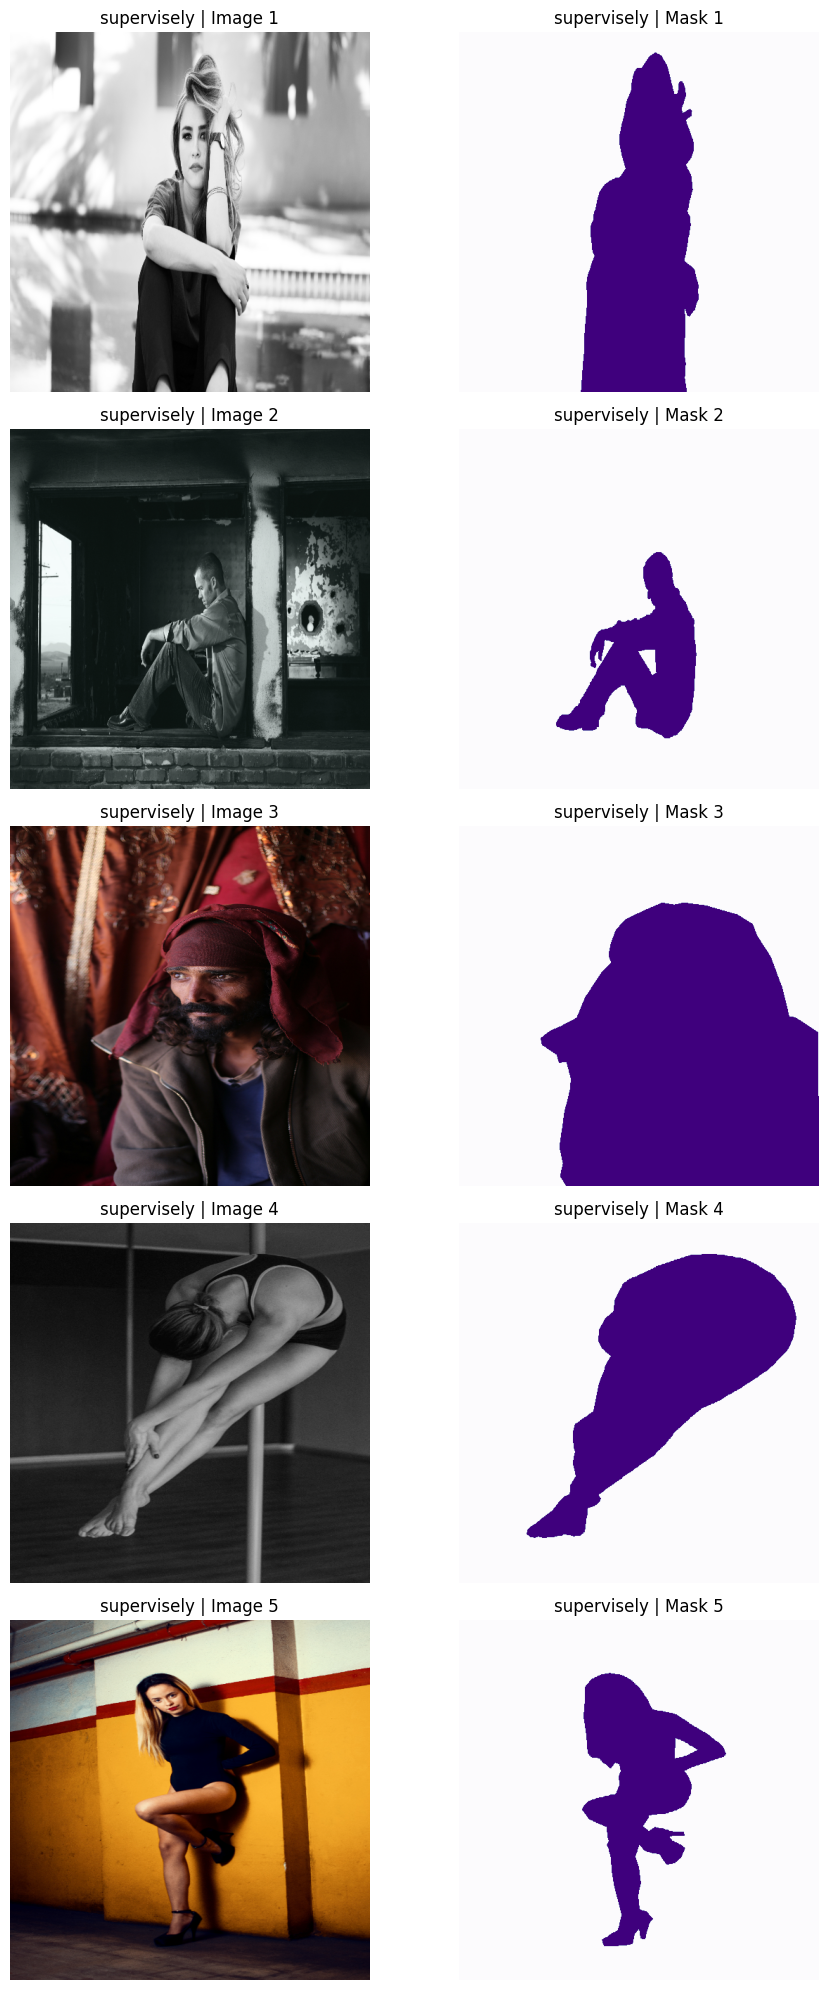

In [67]:
import matplotlib.pyplot as plt
from pathlib import Path

def show_by_source(df, n=5, cmap="Purples", seed=1):
    for src, g in df.groupby("source"):
        g = g.sample(min(n, len(g)), random_state=seed).reset_index(drop=True)

        print(f"\n=== SOURCE: {src} | showing {len(g)} samples ===")

        fig, axes = plt.subplots(len(g), 2, figsize=(10, 4*len(g)))
        if len(g) == 1:
            axes = [axes]  # keep indexing consistent

        for i, row in g.iterrows():
            img_path = row["images"]
            msk_path = row["masks"]

            print(f"[{i}] img: {img_path}")
            print(f"    msk: {msk_path}")

            # load via tf so it matches your pipeline
            img_bytes = tf.io.read_file(img_path)
            img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
            img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
            img = tf.cast(img, tf.float32) / 255.0

            m_bytes = tf.io.read_file(msk_path)
            m = tf.image.decode_image(m_bytes, channels=1, expand_animations=False)
            m = tf.image.resize(m, (IMG_SIZE, IMG_SIZE), method="nearest")
            m = tf.cast(m, tf.float32)

            axes[i][0].imshow(img.numpy())
            axes[i][0].set_title(f"{src} | Image {i+1}")
            axes[i][0].axis("off")

            axes[i][1].imshow(m.numpy().squeeze(), cmap=cmap)
            axes[i][1].set_title(f"{src} | Mask {i+1}")
            axes[i][1].axis("off")

        plt.tight_layout()
        plt.show()

show_by_source(final_df, n=5)

## Modeling

In [68]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

def unet_resnet50(input_shape=(512, 512, 3), C=32, num_classes=1):
    inputs = layers.Input(shape=input_shape)
    base_model = ResNet50(weights="imagenet", include_top=False, input_tensor=inputs)

    c1 = base_model.get_layer("conv1_relu").output
    c2 = base_model.get_layer("conv2_block3_out").output
    c3 = base_model.get_layer("conv3_block4_out").output
    c4 = base_model.get_layer("conv4_block6_out").output
    bottleneck = base_model.get_layer("conv5_block3_out").output

    u6 = layers.Conv2DTranspose(8*C, 2, strides=2, padding="same")(bottleneck)
    u6 = layers.Concatenate()([u6, c4])
    c6 = layers.Conv2D(8*C, 3, activation="relu", padding="same")(u6)
    c6 = layers.BatchNormalization()(c6)
    c6 = layers.Conv2D(8*C, 3, activation="relu", padding="same")(c6)
    c6 = layers.BatchNormalization()(c6)

    u7 = layers.Conv2DTranspose(4*C, 2, strides=2, padding="same")(c6)
    u7 = layers.Concatenate()([u7, c3])
    c7 = layers.Conv2D(4*C, 3, activation="relu", padding="same")(u7)
    c7 = layers.BatchNormalization()(c7)
    c7 = layers.Conv2D(4*C, 3, activation="relu", padding="same")(c7)
    c7 = layers.BatchNormalization()(c7)

    u8 = layers.Conv2DTranspose(2*C, 2, strides=2, padding="same")(c7)
    u8 = layers.Concatenate()([u8, c2])
    c8 = layers.Conv2D(2*C, 3, activation="relu", padding="same")(u8)
    c8 = layers.BatchNormalization()(c8)
    c8 = layers.Conv2D(2*C, 3, activation="relu", padding="same")(c8)
    c8 = layers.BatchNormalization()(c8)

    u9 = layers.Conv2DTranspose(C, 2, strides=2, padding="same")(c8)
    u9 = layers.Concatenate()([u9, c1])
    c9 = layers.Conv2D(C, 3, activation="relu", padding="same")(u9)
    c9 = layers.BatchNormalization()(c9)
    c9 = layers.Conv2D(C, 3, activation="relu", padding="same")(c9)
    c9 = layers.BatchNormalization()(c9)

    u10 = layers.Conv2DTranspose(C, 2, strides=2, padding="same")(c9)
    c10 = layers.Conv2D(C, 3, activation="relu", padding="same")(u10)
    c10 = layers.BatchNormalization()(c10)

    if num_classes == 1:
        outputs = layers.Conv2D(1, 1, activation="sigmoid")(c10)
    else:
        outputs = layers.Conv2D(num_classes, 1, activation="softmax")(c10)

    return models.Model(inputs, outputs)

model = unet_resnet50(input_shape=(512,512,3), C=32)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 518, 518,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 256, 256,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 256, 256,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 256, 256,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 258, 258,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 128, 128,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 128, 128,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 128, 128,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 128, 128,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 128, 128,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 128, 128,  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 128, 128,  │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 128, 128,  │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 128, 128,  │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_3_c

 Total params: 30,557,441 (116.57 MB)

 Trainable params: 30,502,337 (116.36 MB)

 Non-trainable params: 55,104 (215.25 KB)

# *Training*

In [37]:
import sys, site, tensorflow as tf
print("python:", sys.executable)
print("site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")
print("TF:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

python: /home/sam/anaconda3/envs/aiad-tf-gpu/bin/python
site-packages: ['/home/sam/anaconda3/envs/aiad-tf-gpu/lib/python3.10/site-packages']
TF: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [38]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"]="0"
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [39]:
print("Using GPU?" , bool(tf.config.list_physical_devices("GPU")))

Using GPU? True


In [69]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 228s 102ms/step - accuracy: 0.9196 - loss: 0.2333 - val_accuracy: 0.9429 - val_loss: 0.1662
Epoch 2/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 169s 90ms/step - accuracy: 0.9523 - loss: 0.1403 - val_accuracy: 0.9612 - val_loss: 0.1216
Epoch 3/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 170s 90ms/step - accuracy: 0.9603 - loss: 0.1150 - val_accuracy: 0.9599 - val_loss: 0.1082
Epoch 4/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 179s 95ms/step - accuracy: 0.9645 - loss: 0.0992 - val_accuracy: 0.9557 - val_loss: 0.1505
Epoch 5/5
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 170s 90ms/step - accuracy: 0.9677 - loss: 0.0884 - val_accuracy: 0.9595 - val_loss: 0.1161


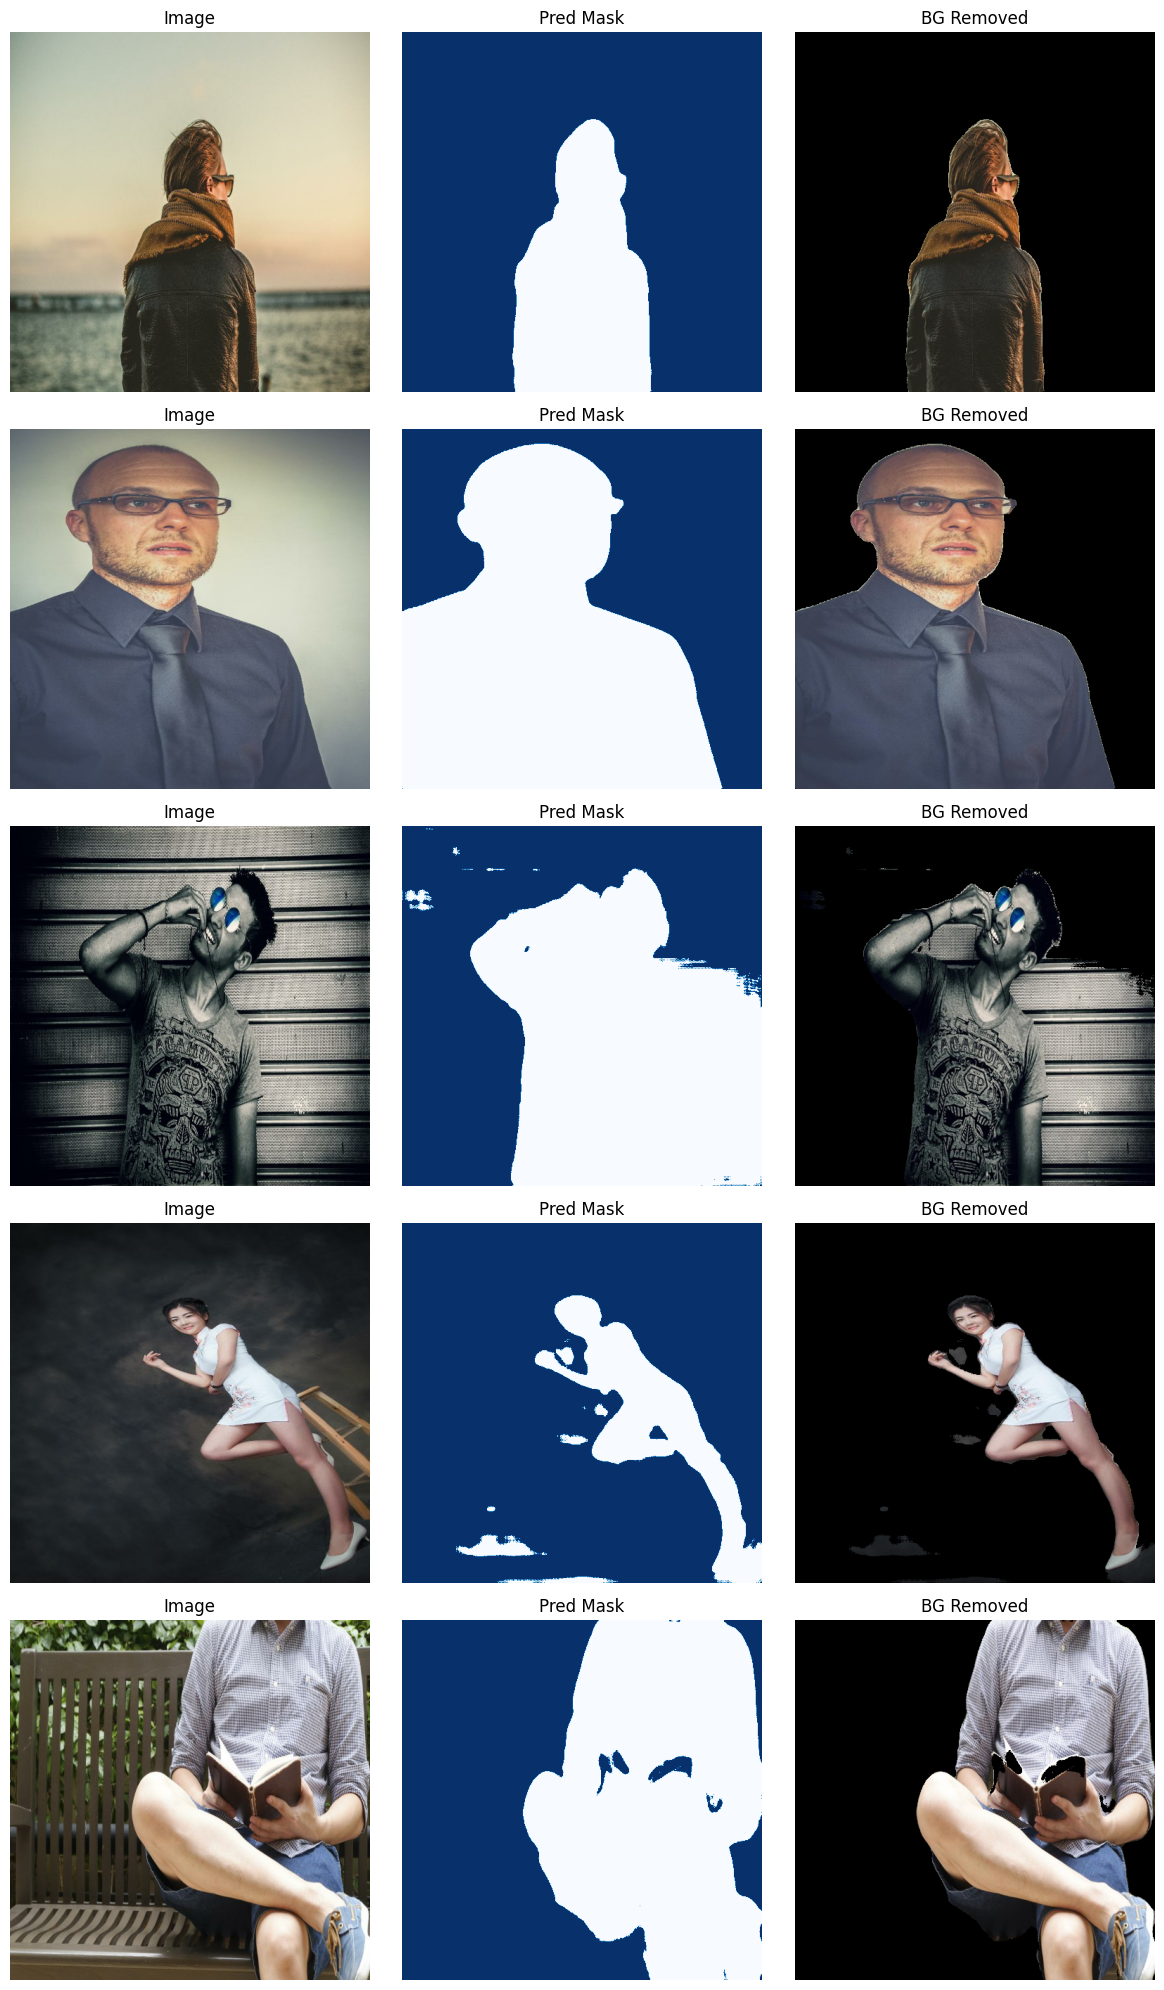

In [ ]:
from PIL import Image

def load_one_image(path: str):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)  # change to decode_png if needed
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

sample_paths = train_df.sample(5, random_state=432)["images"].tolist()

fig, axes = plt.subplots(len(sample_paths), 3, figsize=(12, 4*len(sample_paths)))

for i, path in enumerate(sample_paths):
    img = load_one_image(path)
    pred = model.predict(img[None, ...], verbose=0)[0, ..., 0]
    mask = (pred > 0.5).astype(np.uint8)

    axes[i,0].imshow(img.numpy()); axes[i,0].set_title("Image"); axes[i,0].axis("off")
    axes[i,1].imshow(mask*255, cmap="Blues_r"); axes[i,1].set_title("Pred Mask"); axes[i,1].axis("off")

    orig = np.array(Image.open(path).resize((IMG_SIZE, IMG_SIZE)))
    cut  = orig * np.stack([mask]*3, axis=-1)
    axes[i,2].imshow(cut.astype(np.uint8)); axes[i,2].set_title("BG Removed"); axes[i,2].axis("off")

plt.tight_layout()
plt.show()



In [ ]:
model.save("my_model.keras")